In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, "stores")

In [ ]:
#Loading selected signals
selected_signals = pd.read_parquet(os.path.join(DATA_DIR, "selected_signals.parquet"))

In [45]:
selected_signals.corr()

,ichimoku_conversion,accumulation_distribution_index,macd
ichimoku_conversion,1.000000,0.857898,0.410614
accumulation_distribution_index,0.857898,1.000000,0.413869
macd,0.410614,0.413869,1.000000


In [46]:
# Sharpe for selected signals
sharpe_ratios = selected_signals.mean() / selected_signals.std() * (252 ** 0.5)
sharpe_ratios.sort_values(ascending=False)

ichimoku_conversion                1.676699
accumulation_distribution_index    0.635934
macd                               0.613482
dtype: float64

In [47]:
# Creating equal weight portfolio based on a single signal, with optional sector neutralization
equal_weight_portfolio = selected_signals.sum(axis=1)

Equal Weight Portfolio Sharpe Ratio: 1.19


<Axes: title={'center': 'Equal Weight Portfolio Cumulative Returns'}, xlabel='Date'>

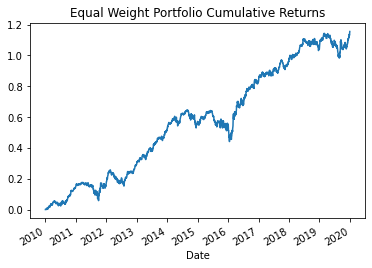

In [48]:
#Equal weight sharpe
print("Equal Weight Portfolio Sharpe Ratio:", np.round(equal_weight_portfolio.mean() / equal_weight_portfolio.std() * (252 ** 0.5), 2))
equal_weight_portfolio.cumsum().plot(title="Equal Weight Portfolio Cumulative Returns")

In [49]:
#Equal Vol Portfolio
vols = selected_signals.std()
inv_vols = 1 / vols
weights = inv_vols / inv_vols.sum()
equal_vol_portfolio = (selected_signals * weights).sum(axis=1)

Equal Vol Portfolio Sharpe Ratio: 1.16


<Axes: title={'center': 'Equal Vol Portfolio Cumulative Returns'}, xlabel='Date'>

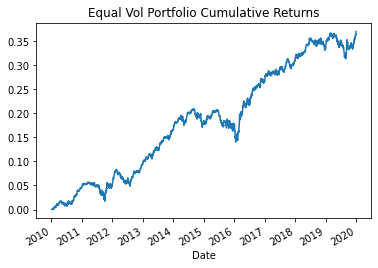

In [50]:
#Equal vol sharpe
print("Equal Vol Portfolio Sharpe Ratio:", np.round(equal_vol_portfolio.mean() / equal_vol_portfolio.std() * (252 ** 0.5), 2))
equal_vol_portfolio.cumsum().plot(title="Equal Vol Portfolio Cumulative Returns")

In [54]:
#Mean Variance Portfolio
cov_matrix = selected_signals.cov()
inv_cov_matrix = np.linalg.inv(cov_matrix)
mu = selected_signals.mean()   # expected returns (or Sharpe proxy)
mv_weights = inv_cov_matrix @ mu
mv_weights = mv_weights / mv_weights.sum()

In [60]:
mv_portfolio = (selected_signals * mv_weights).sum(axis=1)

Mean Variance Portfolio Sharpe Ratio: 2.29


<Axes: title={'center': 'Mean Variance Portfolio Cumulative Returns'}, xlabel='Date'>

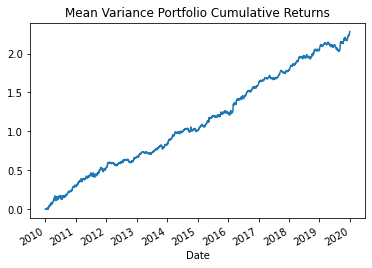

In [61]:
#Mean Variance Optimized Sharpe
print("Mean Variance Portfolio Sharpe Ratio:", np.round(mv_portfolio.mean() / mv_portfolio.std() * (252 ** 0.5), 2))
mv_portfolio.cumsum().plot(title="Mean Variance Portfolio Cumulative Returns")